In [ ]:
import pandas as pd

DATA_PATH = "/content/Corn_Cultivated_Soil_Tested_Dataset.csv"

In [ ]:
df = pd.read_csv(DATA_PATH)
print(df.shape)

(2863, 28)


In [ ]:
df.head()

,district,location,season,planting_date,planting_month,field_size_ha,first_fert_date,second_fert_date,soil_type,soil_condition,...,seed_variety,irrigation_type,rainfall_condition,rainfall_30d_mm,seasonal_rainfall_mm,avg_temperature_c,max_temperature_c,avg_humidity_pct,sunshine_hours,yield_t_ha
0,Anuradhapura,Tambuttegama,Maha,3/1/2020,3,0.660,3/25/2020,4/20/2020,RBE,Poor,...,GT 709,Irrigated,Low,486.201,867.303,26.501,33.798,73.201,6.750,5.5867
1,Monaragala,Buttala,Yala,3/1/2020,3,1.073,3/29/2020,4/17/2020,RBE,Medium,...,GT 200,Mixed,Normal,270.041,615.570,28.179,33.580,77.300,7.486,4.3403
2,Anuradhapura,Horowpathana,Yala,3/1/2020,3,2.260,3/20/2020,4/24/2020,RBE,Medium,...,GT 200,Mixed,Normal,317.407,598.391,28.597,32.499,63.100,6.529,4.3876
3,Ampara,Padiyathalawa,Yala,3/1/2020,3,2.630,3/30/2020,4/29/2020,LHG,Poor,...,Commando,Rainfed,High,468.004,622.009,28.599,31.304,70.099,8.800,4.4649
4,Monaragala,Wellawaya,Yala,3/1/2020,3,0.740,3/16/2020,4/6/2020,Alluvial,Good,...,Jet 999,Irrigated,Normal,195.196,621.199,30.502,34.601,73.895,5.701,3.7739


# Understand the Dataset

In [ ]:
print("Total columns:", len(df.columns))
for c in df.columns:
    print(c)

Total columns: 28
district
location
season
planting_date
planting_month
field_size_ha
first_fert_date
second_fert_date
soil_type
soil_condition
soil_ph
soil_nitrogen_n
soil_phosphorus_p
soil_potassium_k
soil_fertility_index
n_status_class
p_status_class
k_status_class
seed_variety
irrigation_type
rainfall_condition
rainfall_30d_mm
seasonal_rainfall_mm
avg_temperature_c
max_temperature_c
avg_humidity_pct
sunshine_hours
yield_t_ha


> ***Check data types***



In [ ]:
df.dtypes

,0
district,object
location,object
season,object
planting_date,object
planting_month,int64
field_size_ha,float64
first_fert_date,object
second_fert_date,object
soil_type,object
soil_condition,object


> ***Check missing values***



In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
planting_month,2863.0,7.346140,3.107664,2.000,4.0000,9.0000,10.0000,12.000
field_size_ha,2863.0,1.807235,0.728996,0.500,1.2065,1.8200,2.4100,3.500
soil_ph,2863.0,6.249324,0.325743,5.301,6.0310,6.2510,6.4680,7.417
soil_nitrogen_n,2863.0,70.103248,27.619417,9.895,47.0950,69.4910,92.9995,125.009
soil_phosphorus_p,2863.0,15.196262,7.473280,0.990,9.0920,14.8310,21.3280,31.057
soil_potassium_k,2863.0,162.650764,69.730126,19.991,102.4890,154.8400,217.4550,305.010
soil_fertility_index,2863.0,0.573211,0.123461,0.179,0.4910,0.5710,0.6575,0.939
rainfall_30d_mm,2863.0,308.311509,96.983714,109.991,234.2765,300.5060,373.6945,590.007
seasonal_rainfall_mm,2863.0,829.330422,191.832548,465.666,673.5450,820.3020,990.5530,1241.201
avg_temperature_c,2863.0,27.561856,2.056515,22.902,25.9010,27.5960,29.1565,32.502


In [ ]:
print("Districts:", sorted(df["district"].unique()))
print("Seed varieties:", sorted(df["seed_variety"].unique()))
print("Seasons:", sorted(df["season"].unique()))

Districts: ['Ampara', 'Anuradhapura', 'Badulla', 'Matale', 'Monaragala']
Seed varieties: ['Commando', 'GT 200', 'GT 709', 'Jet 999', 'Local Variety', 'Pacific 808']
Seasons: ['Maha', 'Yala']


In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Temperature sanity check

bad_temp = df[df["max_temperature_c"] < df["avg_temperature_c"]]
print("Rows with max_temperature_c < avg_temperature_c:", len(bad_temp))
bad_temp[["avg_temperature_c","max_temperature_c"]].head(10)

Rows with max_temperature_c < avg_temperature_c: 2


,avg_temperature_c,max_temperature_c
542,28.900,28.592
716,25.799,25.547


In [ ]:
import pandas as pd

tmp = df.copy()
tmp["planting_date_dt"] = pd.to_datetime(tmp["planting_date"], format="%m/%d/%Y", errors="coerce")
tmp["first_fert_dt"] = pd.to_datetime(tmp["first_fert_date"], format="%m/%d/%Y", errors="coerce")
tmp["second_fert_dt"] = pd.to_datetime(tmp["second_fert_date"], format="%m/%d/%Y", errors="coerce")

bad_first = tmp[tmp["first_fert_dt"] < tmp["planting_date_dt"]]
bad_second = tmp[tmp["second_fert_dt"] < tmp["first_fert_dt"]]

print("First fert before planting:", len(bad_first))
print("Second fert before first fert:", len(bad_second))

First fert before planting: 2
Second fert before first fert: 0


In [ ]:
checks = {
    "soil_ph_out_of_range": ((df["soil_ph"] < 3.5) | (df["soil_ph"] > 9.0)).sum(),
    "humidity_out_of_range": ((df["avg_humidity_pct"] < 0) | (df["avg_humidity_pct"] > 100)).sum(),
    "negative_rainfall_30d": (df["rainfall_30d_mm"] < 0).sum(),
    "negative_seasonal_rainfall": (df["seasonal_rainfall_mm"] < 0).sum(),
    "negative_yield": (df["yield_t_ha"] < 0).sum(),
    "field_size_too_small": (df["field_size_ha"] < 0.05).sum(),
}
checks

{'soil_ph_out_of_range': np.int64(0),
 'humidity_out_of_range': np.int64(0),
 'negative_rainfall_30d': np.int64(0),
 'negative_seasonal_rainfall': np.int64(0),
 'negative_yield': np.int64(0),
 'field_size_too_small': np.int64(0)}



> ***Target variable check (yield) distribution***



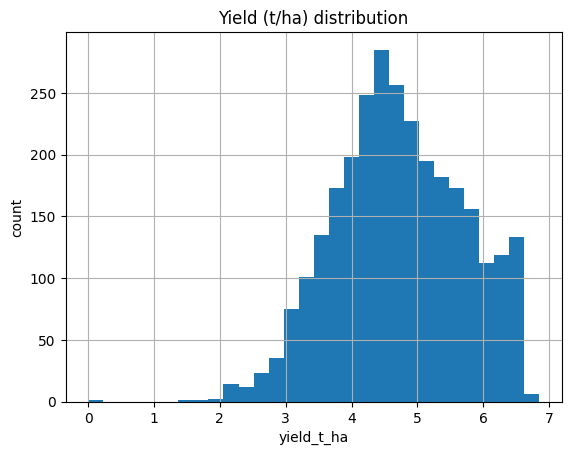

Yield min: 0.0
Yield max: 6.85
Yield mean: 4.724016276632902


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
df["yield_t_ha"].hist(bins=30)
plt.title("Yield (t/ha) distribution")
plt.xlabel("yield_t_ha")
plt.ylabel("count")
plt.show()

print("Yield min:", df["yield_t_ha"].min())
print("Yield max:", df["yield_t_ha"].max())
print("Yield mean:", df["yield_t_ha"].mean())

# Data Cleaning



> ***Data Cleaning + Feature Engineering***



In [ ]:
df2 = df.copy()
print(df2.shape)

(2863, 28)


In [ ]:
#Convert date columns to datetime
import pandas as pd

df2["planting_date_dt"] = pd.to_datetime(df2["planting_date"], format="%m/%d/%Y", errors="coerce")
df2["first_fert_dt"]    = pd.to_datetime(df2["first_fert_date"], format="%m/%d/%Y", errors="coerce")
df2["second_fert_dt"]   = pd.to_datetime(df2["second_fert_date"], format="%m/%d/%Y", errors="coerce")

df2[["planting_date", "planting_date_dt", "first_fert_date", "first_fert_dt"]].head()

,planting_date,planting_date_dt,first_fert_date,first_fert_dt
0,3/1/2020,2020-03-01,3/25/2020,2020-03-25
1,3/1/2020,2020-03-01,3/29/2020,2020-03-29
2,3/1/2020,2020-03-01,3/20/2020,2020-03-20
3,3/1/2020,2020-03-01,3/30/2020,2020-03-30
4,3/1/2020,2020-03-01,3/16/2020,2020-03-16


In [ ]:
#Fix the 2 temperature errors (swap values safely)
mask_temp = df2["max_temperature_c"] < df2["avg_temperature_c"]
df2.loc[mask_temp, ["avg_temperature_c", "max_temperature_c"]] = df2.loc[
    mask_temp, ["max_temperature_c", "avg_temperature_c"]
].values

print("Remaining temp errors:", (df2["max_temperature_c"] < df2["avg_temperature_c"]).sum())

Remaining temp errors: 0


In [ ]:
#Fix fertilizer-before-planting errors (shift fertilizer dates forward)
mask_bad_first = df2["first_fert_dt"] < df2["planting_date_dt"]
df2.loc[mask_bad_first, "first_fert_dt"] = df2.loc[mask_bad_first, "planting_date_dt"] + pd.to_timedelta(14, unit="D")

mask_bad_second = df2["second_fert_dt"] < df2["first_fert_dt"]
df2.loc[mask_bad_second, "second_fert_dt"] = df2.loc[mask_bad_second, "first_fert_dt"] + pd.to_timedelta(21, unit="D")

print("First fert before planting:", (df2["first_fert_dt"] < df2["planting_date_dt"]).sum())
print("Second fert before first fert:", (df2["second_fert_dt"] < df2["first_fert_dt"]).sum())

First fert before planting: 0
Second fert before first fert: 0


In [ ]:
#Feature engineering from dates (create numeric columns)
df2["planting_year"] = df2["planting_date_dt"].dt.year
df2["planting_month_from_date"] = df2["planting_date_dt"].dt.month
df2["planting_dayofyear"] = df2["planting_date_dt"].dt.dayofyear

df2["days_to_first_fert"] = (df2["first_fert_dt"] - df2["planting_date_dt"]).dt.days
df2["days_between_ferts"] = (df2["second_fert_dt"] - df2["first_fert_dt"]).dt.days

df2[["planting_year","planting_month_from_date","planting_dayofyear","days_to_first_fert","days_between_ferts"]].head()

,planting_year,planting_month_from_date,planting_dayofyear,days_to_first_fert,days_between_ferts
0,2020,3,61,24,26
1,2020,3,61,28,19
2,2020,3,61,19,35
3,2020,3,61,29,30
4,2020,3,61,15,21


In [ ]:
df2 = df2.drop(columns=[
    "planting_date", "first_fert_date", "second_fert_date",
    "planting_date_dt", "first_fert_dt", "second_fert_dt"
])

print(df2.shape)
df2.head()

(2863, 30)


,district,location,season,planting_month,field_size_ha,soil_type,soil_condition,soil_ph,soil_nitrogen_n,soil_phosphorus_p,...,avg_temperature_c,max_temperature_c,avg_humidity_pct,sunshine_hours,yield_t_ha,planting_year,planting_month_from_date,planting_dayofyear,days_to_first_fert,days_between_ferts
0,Anuradhapura,Tambuttegama,Maha,3,0.660,RBE,Poor,6.439,89.898,21.509,...,26.501,33.798,73.201,6.750,5.5867,2020,3,61,24,26
1,Monaragala,Buttala,Yala,3,1.073,RBE,Medium,6.274,33.822,10.348,...,28.179,33.580,77.300,7.486,4.3403,2020,3,61,28,19
2,Anuradhapura,Horowpathana,Yala,3,2.260,RBE,Medium,6.389,54.911,5.194,...,28.597,32.499,63.100,6.529,4.3876,2020,3,61,19,35
3,Ampara,Padiyathalawa,Yala,3,2.630,LHG,Poor,6.977,74.803,20.691,...,28.599,31.304,70.099,8.800,4.4649,2020,3,61,29,30
4,Monaragala,Wellawaya,Yala,3,0.740,Alluvial,Good,6.459,46.245,2.690,...,30.502,34.601,73.895,5.701,3.7739,2020,3,61,15,21


In [ ]:
# Clean extra spaces in ALL categorical columns
import re

cat_cols_all = df2.select_dtypes(include="object").columns

for col in cat_cols_all:
    df2[col] = (
        df2[col].astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)  # remove double spaces
    )

In [ ]:
# Standardize soil_type names -> short codes
# Make soil_type consistent
soil_map = {
    "Immature Brown Loams": "IBL",
    "IMMATURE BROWN LOAMS": "IBL",
    "Low Humic Gleys": "LHG",
    "LOW HUMIC GLEYS": "LHG",
    "LOW HUMIC GLEYS ": "LHG",
}

df2["soil_type"] = df2["soil_type"].replace(soil_map)

# Catch slight spelling/spacing variations (safe)
df2.loc[df2["soil_type"].str.contains(r"immature\s*brown\s*loams", case=False, na=False), "soil_type"] = "IBL"
df2.loc[df2["soil_type"].str.contains(r"low\s*humic\s*gleys?", case=False, na=False), "soil_type"] = "LHG"

In [ ]:
#Check soil types (and detect “new/unknown” ones)
print("Unique soil_type values:", sorted(df2["soil_type"].unique()))
print("\nSoil type counts:")
print(df2["soil_type"].value_counts())

Unique soil_type values: ['Alluvial', 'IBL', 'LHG', 'RBE', 'RYP']

Soil type counts:
soil_type
RBE         1911
RYP          694
LHG           93
Alluvial      86
IBL           79
Name: count, dtype: int64


In [ ]:
sorted(df2["soil_type"].unique())

['Alluvial', 'IBL', 'LHG', 'RBE', 'RYP']

# Encoding + Preprocessing Pipeline (OneHotEncoder + Imputer)



> ***Define target (y) and features (X)***



In [ ]:
target = "yield_t_ha"

X = df2.drop(columns=[target])
y = df2[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2863, 29)
y shape: (2863,)



> ***Separate categorical vs numeric columns***


In [ ]:
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)
print("\nCounts -> Categorical:", len(cat_cols), "Numeric:", len(num_cols))

Categorical columns: ['district', 'location', 'season', 'soil_type', 'soil_condition', 'n_status_class', 'p_status_class', 'k_status_class', 'seed_variety', 'irrigation_type', 'rainfall_condition']
Numeric columns: ['planting_month', 'field_size_ha', 'soil_ph', 'soil_nitrogen_n', 'soil_phosphorus_p', 'soil_potassium_k', 'soil_fertility_index', 'rainfall_30d_mm', 'seasonal_rainfall_mm', 'avg_temperature_c', 'max_temperature_c', 'avg_humidity_pct', 'sunshine_hours', 'planting_year', 'planting_month_from_date', 'planting_dayofyear', 'days_to_first_fert', 'days_between_ferts']

Counts -> Categorical: 11 Numeric: 18




> ***Build the preprocessing pipeline***



In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

preprocess

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['planting_month', 'field_size_ha', 'soil_ph',
                                  'soil_nitrogen_n', 'soil_phosphorus_p',
                                  'soil_potassium_k', 'soil_fertility_index',
                                  'rainfall_30d_mm', 'seasonal_rainfall_mm',
                                  'avg_temperature_c', 'max_temperature_c',
                                  'avg_humidity_pct', 'sunshine_hours',
                                  'planti...
                                  'planting_dayofyear', 'days_to_first_fert',
                                  'days_between_ferts']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['district', 'location', 'season', 'soil_type',
                                  'soil_condition', 'n_status_class',
                                  'p_status_class', 'k_status_class',
                                  'seed_variety', 'irrigation_type',
                                  'rainfall_condition'])])



> ***Train/Test split (80/20)***



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train X:", X_train.shape, "Test X:", X_test.shape)
print("Train y:", y_train.shape, "Test y:", y_test.shape)

Train X: (2290, 29) Test X: (573, 29)
Train y: (2290,) Test y: (573,)


# Train 3 Models + Evaluate + Pick Best

```
# Ready to Train : LinearRegression, RandomForestRegressor, XGBoostRegressor
```
And evaluate using:

*   MAE (lower is better)

*   RMSE (lower is better)

*   R² (higher is better, max 1)




> Imports for Models



In [ ]:
#Install XGBoost
!pip -q install xgboost

In [ ]:
#Import other libraries
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [ ]:
#Create an evaluation function
def evaluate(pipe, X_test, y_test, name="Model"):
    preds = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    print(name)
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2  :", round(r2, 4))

    return mae, rmse, r2



> ***Train Model 1 — Linear Regression***



In [ ]:
lin_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

lin_pipe.fit(X_train, y_train)

lin_mae, lin_rmse, lin_r2 = evaluate(lin_pipe, X_test, y_test, "LinearRegression")

LinearRegression
MAE : 0.5595
RMSE: 0.7008
R2  : 0.4684




> ***Train Model 2 — RandomForestRegressor***



In [ ]:
rf_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipe.fit(X_train, y_train)

rf_mae, rf_rmse, rf_r2 = evaluate(rf_pipe, X_test, y_test, "RandomForestRegressor")

RandomForestRegressor
MAE : 0.5386
RMSE: 0.6803
R2  : 0.499




> ***Train Model 3 — XGBoostRegressor***



In [ ]:
xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    ))
])

xgb_pipe.fit(X_train, y_train)

xgb_mae, xgb_rmse, xgb_r2 = evaluate(xgb_pipe, X_test, y_test, "XGBoostRegressor")

XGBoostRegressor
MAE : 0.5038
RMSE: 0.6291
R2  : 0.5717




> ***Model Comparison Table***


In [ ]:
results_df = pd.DataFrame([
    ["LinearRegression", lin_mae, lin_rmse, lin_r2],
    ["RandomForestRegressor", rf_mae, rf_rmse, rf_r2],
    ["XGBoostRegressor", xgb_mae, xgb_rmse, xgb_r2],
], columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")

results_df

,Model,MAE,RMSE,R2
2,XGBoostRegressor,0.503778,0.629060,0.571664
1,RandomForestRegressor,0.538626,0.680296,0.499048
0,LinearRegression,0.559522,0.700816,0.468372


# Cross Validation

In [ ]:
#Import cross_val_score
from sklearn.model_selection import cross_val_score



> ***Cross-validate LinearRegression (5 folds)***



In [ ]:
lin_cv_rmse = -cross_val_score(
    lin_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("LinearRegression CV RMSE mean:", round(lin_cv_rmse.mean(), 4))
print("LinearRegression CV RMSE std :", round(lin_cv_rmse.std(), 4))

LinearRegression CV RMSE mean: 0.7092
LinearRegression CV RMSE std : 0.0135




> ***Cross-validate RandomForest (5 folds)***



In [ ]:
rf_cv_rmse = -cross_val_score(
    rf_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("RandomForest CV RMSE mean:", round(rf_cv_rmse.mean(), 4))
print("RandomForest CV RMSE std :", round(rf_cv_rmse.std(), 4))

RandomForest CV RMSE mean: 0.7215
RandomForest CV RMSE std : 0.0176




> ***Cross-validate XGBoost (5 folds)***



In [ ]:
xgb_cv_rmse = -cross_val_score(
    xgb_pipe, X, y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

print("XGBoost CV RMSE mean:", round(xgb_cv_rmse.mean(), 4))
print("XGBoost CV RMSE std :", round(xgb_cv_rmse.std(), 4))

XGBoost CV RMSE mean: 0.6823
XGBoost CV RMSE std : 0.0236




> ***CV comparison table***



In [ ]:
cv_df = pd.DataFrame([
    ["LinearRegression", lin_cv_rmse.mean(), lin_cv_rmse.std()],
    ["RandomForestRegressor", rf_cv_rmse.mean(), rf_cv_rmse.std()],
    ["XGBoostRegressor", xgb_cv_rmse.mean(), xgb_cv_rmse.std()],
], columns=["Model", "CV_RMSE_Mean", "CV_RMSE_Std"]).sort_values("CV_RMSE_Mean")

cv_df

,Model,CV_RMSE_Mean,CV_RMSE_Std
2,XGBoostRegressor,0.682337,0.023574
0,LinearRegression,0.709188,0.013523
1,RandomForestRegressor,0.721541,0.017643


# Save Best Model (XGBoost pipeline)

In [ ]:
#Save pipeline

import joblib
joblib.dump(xgb_pipe, "best_yield_model_xgb.pkl")
print("Saved: best_yield_model_xgb.pkl")

Saved: best_yield_model_xgb.pkl


In [ ]:
#Download
from google.colab import files
files.download("best_yield_model_xgb.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Feature Importance (XGBoost) + Plot



> ***Fit XGBoost pipeline again (make sure it’s trained)***



In [ ]:
xgb_pipe.fit(X_train, y_train)
print("XGBoost pipeline trained.")

XGBoost pipeline trained.


In [ ]:
# Get the encoded feature names after preprocessing
ohe = xgb_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_feature_names = np.concatenate([num_cols, cat_feature_names])

print("Total final features after encoding:", len(all_feature_names))

Total final features after encoding: 70




> ***Extract XGBoost feature importances + create Top 15 table***



In [ ]:
xgb_model = xgb_pipe.named_steps["model"]

importances = xgb_model.feature_importances_

fi = pd.DataFrame({
    "feature": all_feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(15)

,feature,importance
49,n_status_class_High,0.168560
46,soil_condition_Good,0.118245
48,soil_condition_Poor,0.059474
64,irrigation_type_Irrigated,0.035161
3,soil_nitrogen_n,0.032132
6,soil_fertility_index,0.028795
10,max_temperature_c,0.025382
55,k_status_class_High,0.023417
9,avg_temperature_c,0.023219
12,sunshine_hours,0.022703




> ***Plot Top 15 feature importances***



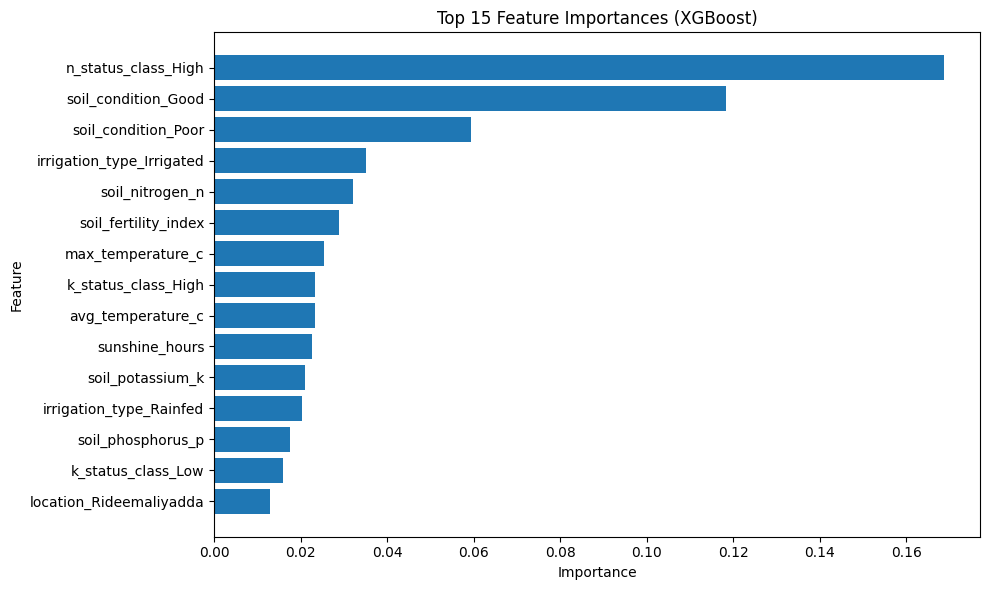

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
top_fi = fi.head(top_n).iloc[::-1]  # reverse for nice plotting

plt.figure(figsize=(10, 6))
plt.barh(top_fi["feature"], top_fi["importance"])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



> ***Check where rainfall + seed_variety features are ranked (Top 50 view)***



In [ ]:
# Show top 50
fi.head(50)

,feature,importance
49,n_status_class_High,0.168560
46,soil_condition_Good,0.118245
48,soil_condition_Poor,0.059474
64,irrigation_type_Irrigated,0.035161
3,soil_nitrogen_n,0.032132
6,soil_fertility_index,0.028795
10,max_temperature_c,0.025382
55,k_status_class_High,0.023417
9,avg_temperature_c,0.023219
12,sunshine_hours,0.022703


In [ ]:
fi[fi["feature"].str.contains("rainfall|seed_variety", case=False, na=False)].head(30)

,feature,importance
8,seasonal_rainfall_mm,0.009310
63,seed_variety_Pacific 808,0.008901
62,seed_variety_Local Variety,0.008586
7,rainfall_30d_mm,0.007162
60,seed_variety_GT 709,0.007061
59,seed_variety_GT 200,0.006287
67,rainfall_condition_High,0.005756
68,rainfall_condition_Low,0.005525
69,rainfall_condition_Normal,0.005433
58,seed_variety_Commando,0.004974




> ***Group importance by original column***



In [ ]:
# Map each encoded feature back to its original column name
def base_feature_name(feat: str) -> str:
    for c in cat_cols:
        prefix = c + "_"
        if feat.startswith(prefix):
            return c
    return feat  # numeric stays same

fi["base_feature"] = fi["feature"].apply(base_feature_name)

group_imp = (
    fi.groupby("base_feature")["importance"]
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

group_imp.head(20)

,base_feature,importance
0,soil_condition,0.187238
1,n_status_class,0.178070
2,location,0.133232
3,irrigation_type,0.060727
4,k_status_class,0.044677
5,seed_variety,0.040057
6,soil_type,0.037398
7,district,0.033822
8,soil_nitrogen_n,0.032132
9,soil_fertility_index,0.028795




> ***Plot grouped importance***



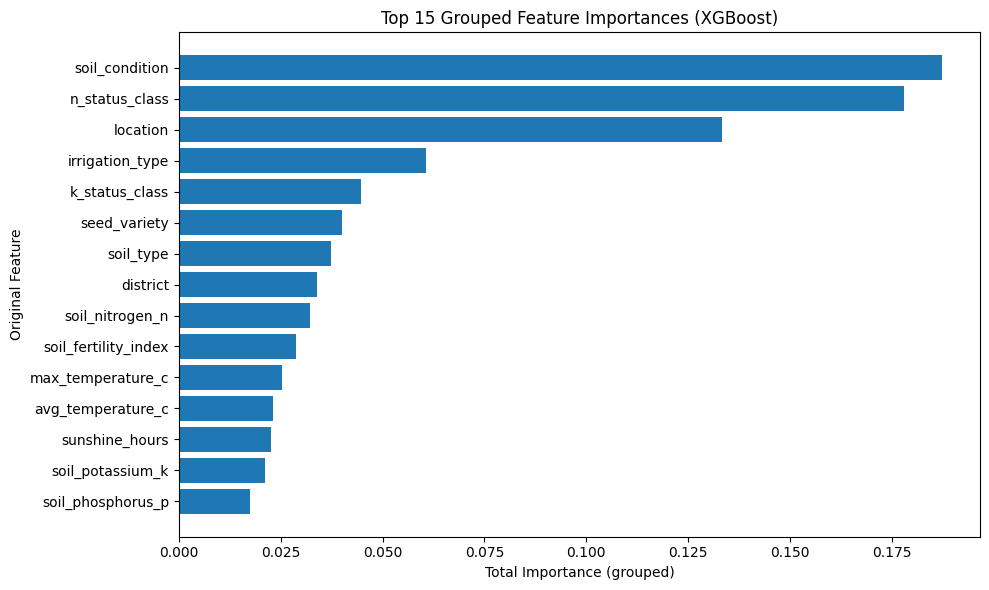

In [ ]:
import matplotlib.pyplot as plt

top_n = 15
tmp = group_imp.head(top_n).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(tmp["base_feature"], tmp["importance"])
plt.title("Top 15 Grouped Feature Importances (XGBoost)")
plt.xlabel("Total Importance (grouped)")
plt.ylabel("Original Feature")
plt.tight_layout()
plt.show()

In [ ]:
fi[fi["base_feature"] == "seed_variety"].head(20)

,feature,importance,base_feature
63,seed_variety_Pacific 808,0.008901,seed_variety
62,seed_variety_Local Variety,0.008586,seed_variety
60,seed_variety_GT 709,0.007061,seed_variety
59,seed_variety_GT 200,0.006287,seed_variety
58,seed_variety_Commando,0.004974,seed_variety
61,seed_variety_Jet 999,0.004248,seed_variety


*Top-15 shows individual encoded features. Since seed_variety is one-hot encoded, its influence is split across multiple columns, so it may not appear in Top-15. When I group importances by original column, seed variety and rainfall influence become visible.*


In [ ]:
#Predict on test set
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

y_pred = xgb_pipe.predict(X_test)

In [ ]:
#Calculate metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

R² Score: 0.5717
RMSE: 0.6291
MAE: 0.5038


In [ ]:
# Testing MAPE Value
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE (%):", round(mape, 2))

MAPE (%): 11.73




> XGBoost Regressor – Prediction + Accuracy (MAPE-based)






In [ ]:
# XGBRegressior Model Accuracy using MAPE
accuracy = 100 - mape
print("Accuracy (%):", round(accuracy, 2))

Accuracy (%): 88.27




> Linear Regression – Prediction + Accuracy (MAPE-based)



In [ ]:
# ===============================
# Linear Regression Evaluation
# ===============================

# Predict
y_pred_lin = lin_pipe.predict(X_test)

# Metrics
r2_lin = r2_score(y_test, y_pred_lin)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)

print("Linear Regression Results")
print("R² Score:", round(r2_lin, 4))
print("RMSE:", round(rmse_lin, 4))
print("MAE:", round(mae_lin, 4))

# MAPE
mape_lin = np.mean(np.abs((y_test - y_pred_lin) / y_test)) * 100
accuracy_lin = 100 - mape_lin

print("MAPE (%):", round(mape_lin, 2))
print("Accuracy (%):", round(accuracy_lin, 2))


Linear Regression Results
R² Score: 0.4684
RMSE: 0.7008
MAE: 0.5595
MAPE (%): 13.1
Accuracy (%): 86.9




> Random Forest – Prediction + Accuracy (MAPE-based)


In [ ]:
# ===============================
# Random Forest Evaluation
# ===============================

# Predict
y_pred_rf = rf_pipe.predict(X_test)

# Metrics
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Results")
print("R² Score:", round(r2_rf, 4))
print("RMSE:", round(rmse_rf, 4))
print("MAE:", round(mae_rf, 4))

# MAPE
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100
accuracy_rf = 100 - mape_rf

print("MAPE (%):", round(mape_rf, 2))
print("Accuracy (%):", round(accuracy_rf, 2))

Random Forest Results
R² Score: 0.499
RMSE: 0.6803
MAE: 0.5386
MAPE (%): 12.62
Accuracy (%): 87.38




> XGBoost Regression – Prediction + Accuracy (MAPE-based)



In [ ]:
# ===============================
# XGBoost Regression Evaluation
# ===============================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Predict
y_pred_xgb = xgb_pipe.predict(X_test)

# Metrics
r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print("XGBoost Regression Results")
print("R² Score:", round(r2_xgb, 4))
print("RMSE:", round(rmse_xgb, 4))
print("MAE:", round(mae_xgb, 4))

# MAPE
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100
accuracy_xgb = 100 - mape_xgb

print("MAPE (%):", round(mape_xgb, 2))
print("Accuracy (%):", round(accuracy_xgb, 2))

XGBoost Regression Results
R² Score: 0.5717
RMSE: 0.6291
MAE: 0.5038
MAPE (%): 11.73
Accuracy (%): 88.27


In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [r2_lin, r2_rf, r2_xgb],
    "RMSE": [rmse_lin, rmse_rf, rmse_xgb],
    "MAE": [mae_lin, mae_rf, mae_xgb],
    "MAPE (%)": [mape_lin, mape_rf, mape_xgb],
    "Accuracy (%)": [accuracy_lin, accuracy_rf, accuracy_xgb]
}).round(3)

comparison_df.sort_values("Accuracy (%)", ascending=False)

,Model,R²,RMSE,MAE,MAPE (%),Accuracy (%)
2,XGBoost,0.572,0.629,0.504,11.732,88.268
1,Random Forest,0.499,0.680,0.539,12.623,87.377
0,Linear Regression,0.468,0.701,0.560,13.098,86.902




> Accuracy Comparison Bar Chart



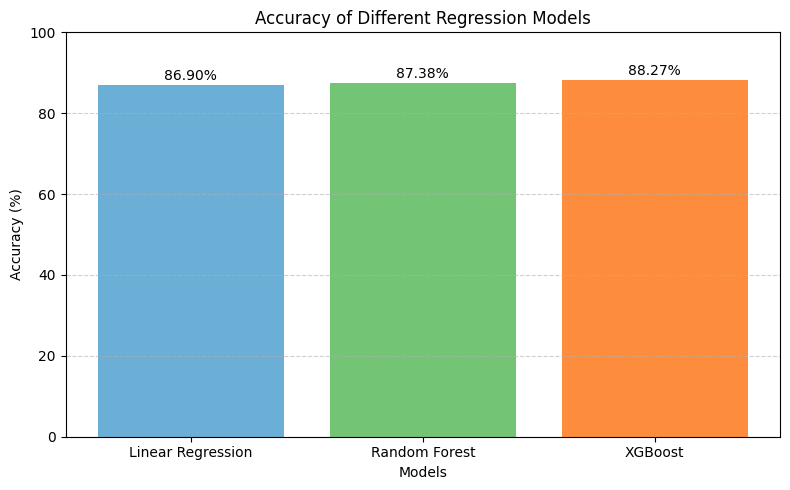

In [ ]:
import matplotlib.pyplot as plt

# Model names and accuracies
models = ["Linear Regression", "Random Forest", "XGBoost"]
accuracies = [accuracy_lin, accuracy_rf, accuracy_xgb]

# Define 3 different colors
colors = ["#6baed6", "#74c476", "#fd8d3c"]
# blue, green, orange (research-paper friendly)

plt.figure(figsize=(8, 5))

bars = plt.bar(models, accuracies, color=colors)

# Add value labels on bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        f"{yval:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Axis & title
plt.ylim(0, 100)
plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Accuracy of Different Regression Models")

# Grid (optional but looks professional)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()